# Model Tuning for AI4I 2020 Predictive Maintenance
    This notebook covers:
    - Cross-validation Stratified KFold
    - Calibration des probabilités (Platt / Isotonic)
    - SHAP
    
Dataset: AI4I 2020 Predictive Maintenance (UCI ML Repository)
<a href="https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset">#

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import shap

import joblib

from PIL import Image
import io

c:\Users\Souissi Hedi\OneDrive\Documents\RFC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/ai4i2020.csv")

df = df.rename(columns={
    "Air temperature [K]": "Air temperature",
    "Process temperature [K]": "Process temperature",
    "Rotational speed [rpm]": "Rotational speed",
    "Torque [Nm]": "Torque",
    "Tool wear [min]": "Tool wear"
})
df['temp_diff'] = df['Process temperature'] - df['Air temperature']
df['power'] = df['Rotational speed'] * df['Torque']  
df['wear_per_rpm'] = df['Tool wear'] / (df['Rotational speed'] + 1e-6) 

y = df["Machine failure"]
X = df.drop(columns=["Machine failure", "UDI", "Product ID",
                    "TWF", "HDF", "PWF", "OSF", "RNF"])
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(df, X_train, X_test, y_train, y_test, RANDOM_STATE)
df.head()

        UDI Product ID Type  Air temperature  Process temperature  \
0         1     M14860    M            298.1                308.6   
1         2     L47181    L            298.2                308.7   
2         3     L47182    L            298.1                308.5   
3         4     L47183    L            298.2                308.6   
4         5     L47184    L            298.2                308.7   
...     ...        ...  ...              ...                  ...   
9995   9996     M24855    M            298.8                308.4   
9996   9997     H39410    H            298.9                308.4   
9997   9998     M24857    M            299.0                308.6   
9998   9999     H39412    H            299.0                308.7   
9999  10000     M24859    M            299.0                308.7   

      Rotational speed  Torque  Tool wear  Machine failure  TWF  HDF  PWF  \
0                 1551    42.8          0                0    0    0    0   
1                

,UDI,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff,power,wear_per_rpm
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392


In [3]:


# 1. Charger le pipeline sauvegardé
loaded_pipeline = joblib.load("../artifacts/best_model.pkl")

# 2. Extraire le preprocessor et le XGBoost
preprocessor = loaded_pipeline.named_steps['preprocessor']
xgboost_model = loaded_pipeline.named_steps['model']

print("Preprocessor extrait :", type(preprocessor))
print("XGBoost extrait :", type(xgboost_model))

# 3. Transformer les données d'entraînement UNE SEULE FOIS
# (on utilise .transform car le preprocessor est déjà fitté dans best_model.pkl)
X_train_transformed = preprocessor.transform(X_train)

# Convertir en dense si c'est sparse (OneHotEncoder peut produire du sparse)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

print("Shape des données transformées :", X_train_transformed.shape)  # devrait être (8000, 11)

# 4. Cross-validation sur les données numpy + XGBoost seul
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aps = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_transformed, y_train), 1):
    X_tr  = X_train_transformed[train_idx]
    X_val = X_train_transformed[val_idx]
    y_tr  = y_train.iloc[train_idx].values.ravel()
    y_val = y_train.iloc[val_idx].values.ravel()

    # Entraîner XGBoost seul
    xgboost_model.fit(X_tr, y_tr)

    # Prédictions
    y_score = xgboost_model.predict_proba(X_val)[:, 1]
    ap = average_precision_score(y_val, y_score)
    aps.append(ap)
    print(f"Fold {fold} AP: {ap:.4f}")

print(f"\nCross-Validation Average Precision : {np.mean(aps):.4f} ± {np.std(aps):.4f}")

Preprocessor extrait : <class 'sklearn.compose._column_transformer.ColumnTransformer'>
XGBoost extrait : <class 'xgboost.sklearn.XGBClassifier'>
Shape des données transformées : (8000, 11)
Fold 1 AP: 0.8999
Fold 2 AP: 0.8046
Fold 3 AP: 0.8599
Fold 4 AP: 0.8796
Fold 5 AP: 0.8572

Cross-Validation Average Precision : 0.8603 ± 0.0318


In [4]:
feature_names = preprocessor.get_feature_names_out()
print("Noms des features :", feature_names.tolist())

Noms des features : ['num__Air temperature', 'num__Process temperature', 'num__Rotational speed', 'num__Torque', 'num__Tool wear', 'num__temp_diff', 'num__power', 'num__wear_per_rpm', 'cat__Type_H', 'cat__Type_L', 'cat__Type_M']


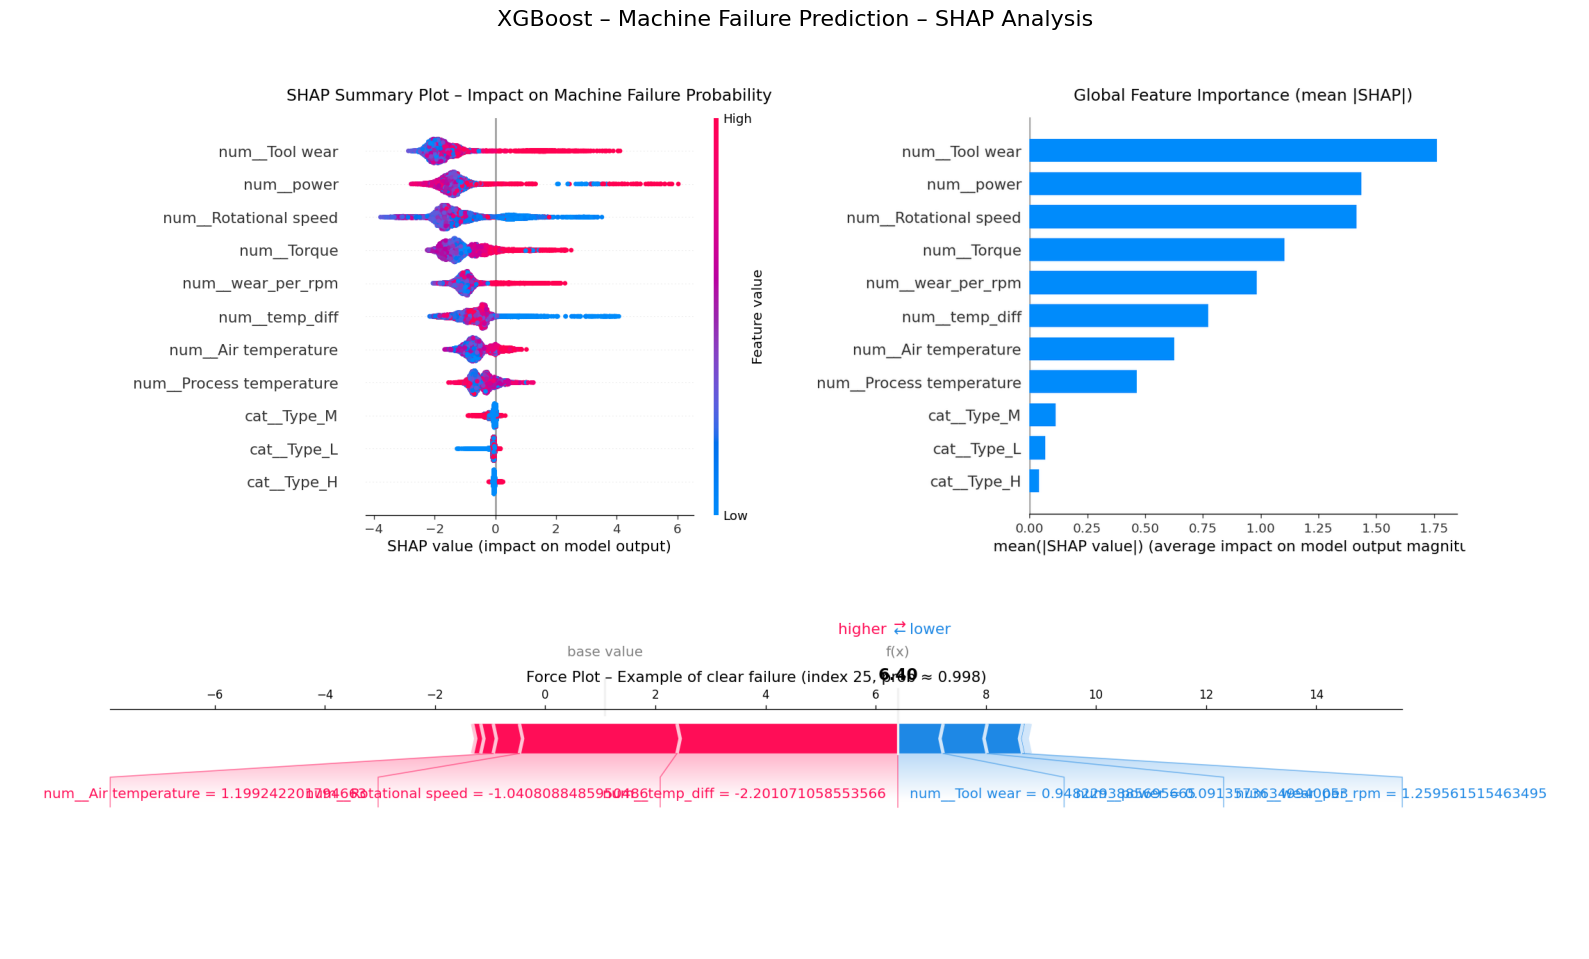

In [5]:

# Utilise les données transformées et le modèle XGBoost seul
explainer = shap.TreeExplainer(xgboost_model)
shap_values = explainer.shap_values(X_train_transformed)


# Exemple local (première panne bien détectée par exemple)
probas = xgboost_model.predict_proba(X_train_transformed)[:, 1]
idx_example = np.where((y_train == 1) & (probas > 0.8))[0][0] if np.any((y_train == 1) & (probas > 0.8)) else 0

# ─── 1. Beeswarm ───────────────────────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary Plot – Impact on Machine Failure Probability", fontsize=14, pad=15)
plt.tight_layout()
buf1 = io.BytesIO()
plt.savefig(buf1, format='png', dpi=120, bbox_inches='tight')
plt.close()
buf1.seek(0)

# ─── 2. Bar (importance) ───────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance (mean |SHAP|)", fontsize=14, pad=15)
plt.tight_layout()
buf2 = io.BytesIO()
plt.savefig(buf2, format='png', dpi=120, bbox_inches='tight')
plt.close()
buf2.seek(0)

# ─── 3. Force plot (local) ─────────────────────────────
probas = xgboost_model.predict_proba(X_train_transformed)[:, 1]
pos_high = np.where((y_train == 1) & (probas >= 0.80))[0]
idx = pos_high[0] if len(pos_high) > 0 else np.argmax(probas)

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_train_transformed.iloc[idx] if hasattr(X_train_transformed, 'iloc') else X_train_transformed[idx],
    feature_names=feature_names,
    matplotlib=True,
    link="identity",          # ← "logit" if you want probability scale
    show=False
)
plt.title(f"Force Plot – Example of clear failure (index {idx}, prob ≈ {probas[idx]:.3f})", fontsize=13)
buf3 = io.BytesIO()
plt.savefig(buf3, format='png', dpi=120, bbox_inches='tight', pad_inches=0.4)
plt.close()
buf3.seek(0)

# ─── Combine: beeswarm + bar SIDE BY SIDE, force below ───────
img1 = Image.open(buf1)   # beeswarm
img2 = Image.open(buf2)   # bar
img3 = Image.open(buf3)   # force

# Resize bar plot to match beeswarm height (most people prefer same height)
h_target = img1.height
img2 = img2.resize((int(img2.width * h_target / img2.height), h_target), Image.Resampling.LANCZOS)

w1, h1 = img1.size
w2, h2 = img2.size      # now h2 ≈ h1
w3, h3 = img3.size

# Top row: beeswarm | bar
top_width = w1 + w2 + 40          # 40 = gap between them
top_height = max(h1, h2)

# Bottom: force plot (usually wider)
bottom_width = w3
bottom_height = h3

# Final canvas
total_width = max(top_width, bottom_width)
total_height = top_height + bottom_height + 80   # extra space for titles + gap

final = Image.new('RGB', (total_width, total_height), (255, 255, 255))

# Paste top row (centered horizontally if force is wider)
x_offset = (total_width - top_width) // 2
final.paste(img1, (x_offset, 30))
final.paste(img2, (x_offset + w1 + 40, 30))

# Paste force plot below (also centered)
x_offset_bottom = (total_width - bottom_width) // 2
final.paste(img3, (x_offset_bottom, top_height + 60))

# Show everything
plt.figure(figsize=(16, 12))   # adjust if needed (wider than before)
plt.imshow(final)
plt.axis('off')
plt.title("XGBoost – Machine Failure Prediction – SHAP Analysis", fontsize=16, pad=25)
plt.tight_layout()
plt.show()

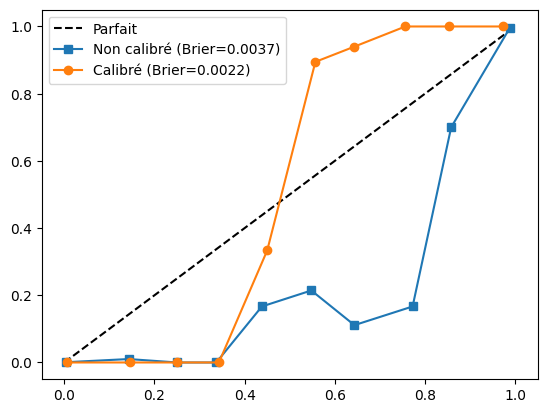

: 

In [ ]:
# Calibrateur Isotonic (souvent meilleur ici)
calibrated = CalibratedClassifierCV(xgboost_model, method='isotonic', cv=3)
calibrated.fit(X_train_transformed, y_train)

# Comparaison
proba_uncal = xgboost_model.predict_proba(X_train_transformed)[:,1]
proba_cal = calibrated.predict_proba(X_train_transformed)[:,1]

# Reliability diagram
frac_pos_uncal, pred_pos_uncal = calibration_curve(y_train, proba_uncal, n_bins=10)
frac_pos_cal, pred_pos_cal = calibration_curve(y_train, proba_cal, n_bins=10)

plt.plot([0,1], [0,1], "k--", label="Parfait")
plt.plot(pred_pos_uncal, frac_pos_uncal, "s-", label=f"Non calibré (Brier={brier_score_loss(y_train, proba_uncal):.4f})")
plt.plot(pred_pos_cal, frac_pos_cal, "o-", label=f"Calibré (Brier={brier_score_loss(y_train, proba_cal):.4f})")
plt.legend(); plt.show()